# Laborator 3 — Recunoașterea automată a obiectelor din imagine

#### Corețchi Mihai
#### Set de date: `Fruits-360` (sursa oficială GitHub — `Horea94/Fruit-Images-Dataset`)
#### Obiectiv: recunoașterea **sortului de fruct** dintr-o imagine (ex.: `Apple Granny Smith`, `Apple Golden 1`, `Banana`, ...).


## 1. Importul bibliotecilor și configurarea mediului


In [1]:
import os
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout,
    GlobalAveragePooling2D, Dense, Activation,
    Rescaling, RandomFlip, RandomRotation, RandomZoom,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import SparseTopKCategoricalAccuracy

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, f1_score,
)

%matplotlib inline
sns.set_theme(style="whitegrid")
tf.keras.utils.set_random_seed(101)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 2. Obținerea și analiza exploratorie a datelor



In [2]:
![ -d Fruit-Images-Dataset ] || git clone --depth 1 https://github.com/Horea94/Fruit-Images-Dataset.git

# Repo-ul conține Training/ și Test/ la rădăcină; detectăm robust calea
train_dir = next(
    p for p in glob.glob("Fruit-Images-Dataset/**/Training", recursive=True)
    if os.path.isdir(p)
)
test_dir = os.path.join(os.path.dirname(train_dir), "Test")
print("Training:", train_dir)
print("Test:    ", test_dir)


Cloning into 'Fruit-Images-Dataset'...
remote: Enumerating objects: 90769, done.
remote: Counting objects: 100% (90769/90769), done.
remote: Compressing objects: 100% (90767/90767), done.
remote: Total 90769 (delta 1), reused 90683 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (90769/90769), 718.93 MiB | 24.61 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (90503/90503), done.
Training: Fruit-Images-Dataset/Training
Test:     Fruit-Images-Dataset/Test


In [3]:
class_dirs = sorted(
    d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))
)
counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in class_dirs}
eda_df = pd.DataFrame({"class": list(counts), "count": list(counts.values())})

print("Număr de clase (sorturi):", len(class_dirs))
print("Total imagini (Training):", eda_df["count"].sum())
print(
    f"Imagini per clasă — min: {eda_df['count'].min()}, "
    f"max: {eda_df['count'].max()}, mediu: {eda_df['count'].mean():.0f}"
)
eda_df.head(10)


Număr de clase (sorturi): 131
Total imagini (Training): 67692
Imagini per clasă — min: 297, max: 984, mediu: 517


,class,count
0,Apple Braeburn,492
1,Apple Crimson Snow,444
2,Apple Golden 1,480
3,Apple Golden 2,492
4,Apple Golden 3,481
5,Apple Granny Smith,492
6,Apple Pink Lady,456
7,Apple Red 1,492
8,Apple Red 2,492
9,Apple Red 3,429


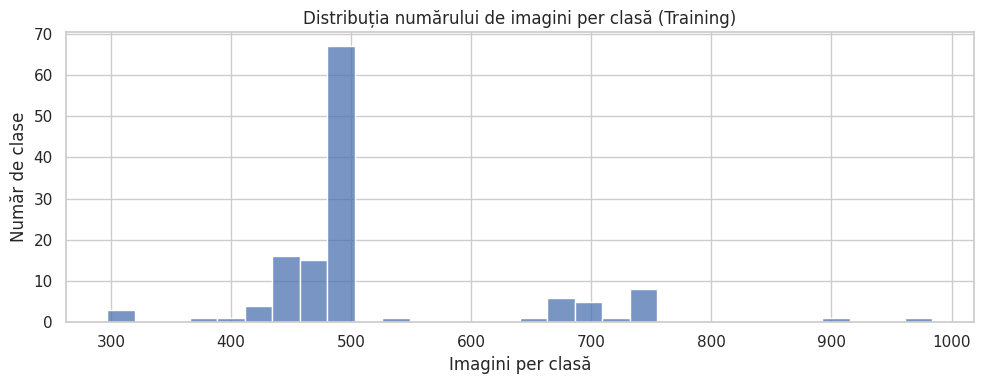

In [4]:
plt.figure(figsize=(10, 4))
sns.histplot(eda_df["count"], bins=30)
plt.title("Distribuția numărului de imagini per clasă (Training)")
plt.xlabel("Imagini per clasă")
plt.ylabel("Număr de clase")
plt.tight_layout()
plt.show()


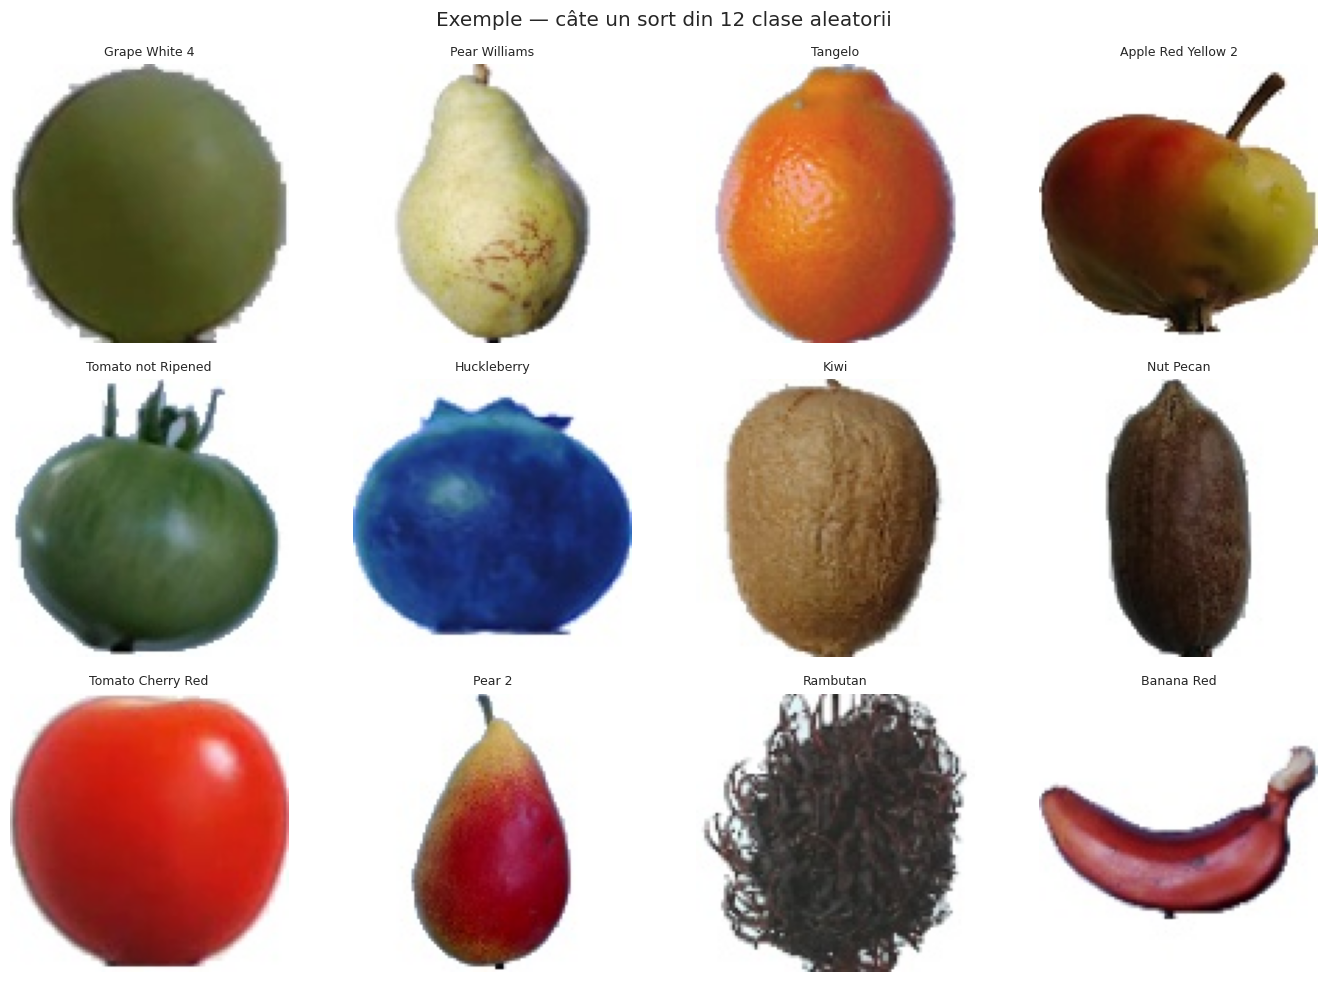

In [5]:
sample_classes = random.sample(class_dirs, 12)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, name in zip(axes.flat, sample_classes):
    folder = os.path.join(train_dir, name)
    img_file = os.listdir(folder)[0]
    ax.imshow(Image.open(os.path.join(folder, img_file)).convert("RGB"))
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.suptitle("Exemple — câte un sort din 12 clase aleatorii")
plt.tight_layout()
plt.show()


## 3. Pregătirea datelor

Folosim `tf.keras.utils.image_dataset_from_directory`, care citește imaginile **în loturi (streaming)** — esențial aici, fiindcă setul are zeci de mii de imagini și nu încape comod în memorie ca un singur tablou NumPy. Etichetele sunt **indici întregi** (`label_mode="int"`), potrivite pentru `sparse_categorical_crossentropy`.

- Din `Training/` desprindem **15% pentru validare** (`validation_split` + `subset`, aceeași sămânță 101).
- `Test/` rămâne neatins ca set de **test** independent.
- Folosim doar `prefetch()` (suprapune citirea datelor cu calculul pe GPU).

Setul Fruits-360 este aproximativ echilibrat (număr similar de imagini per sort), deci nu aplicăm ponderi de clasă.

In [6]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="training",
    seed=101,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="validation",
    seed=101,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Număr de clase:", num_classes)


Found 67692 files belonging to 131 classes.
Using 57539 files for training.
Found 67692 files belonging to 131 classes.
Using 10153 files for validation.
Found 22688 files belonging to 131 classes.
Număr de clase: 131


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000, seed=101).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 4. Data Augmentation

Imaginile Fruits-360 sunt foarte „curate” (fruct centrat, fundal alb). Pentru ca modelul să generalizeze la fotografii reale (fruct rotit, ușor mărit), aplicăm augmentări aleatorii — **flip orizontal**, **rotație** și **zoom**. Augmentarea este un mic `Sequential` integrat la începutul modelului și se aplică **doar la antrenare** (`training=True`); pe validare/test nu se aplică.


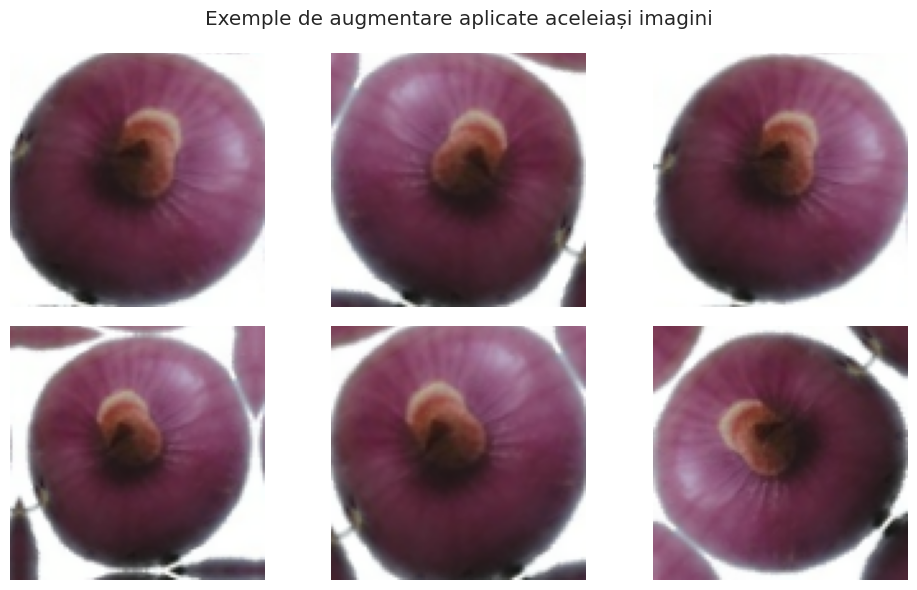

In [8]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.1),
], name="data_augmentation")

# Previzualizare pe o imagine din primul batch
for images, _ in train_ds.take(1):
    sample = images[0]
    break

plt.figure(figsize=(10, 6))
for i in range(6):
    aug = data_augmentation(tf.expand_dims(sample, 0), training=True)
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(tf.cast(aug[0], tf.uint8).numpy())
    plt.axis("off")
plt.suptitle("Exemple de augmentare aplicate aceleiași imagini")
plt.tight_layout()
plt.show()


## 5. Crearea modelului CNN

Construim o CNN proprie cu **3 blocuri convoluționale** urmate de un cap dens. Alegerile de arhitectură :

- **Număr de filtre crescător** `32 → 64 → 128`: straturile timpurii învață tipare simple (margini, culori), cele adânci tipare mai abstracte (forma/textura fructului), pe măsură ce harta spațială se micșorează.
- **Filtre `3×3`**: standardul modern — eficiente și suficiente pentru imagini `100×100`.
- **Padding**: `same` în primele blocuri (păstrează dimensiunea, util când harta e încă mare), `valid` în ultimul (reduce dimensiunea spre cap).
- **MaxPooling2D** după fiecare bloc: reduce rezoluția și costul de calcul, oferă invarianță la mici deplasări.
- **BatchNormalization**: stabilizează și accelerează antrenarea.
- **Dropout** crescător (`0.2 → 0.3 → 0.4`): regularizare împotriva supra-antrenării, mai agresiv aproape de stratul dens.
- **GlobalAveragePooling2D** în loc de `Flatten`: considerabil mai puțini parametri și mai puțin overfitting.
- **Ieșire** `Dense(num_classes, softmax)`: o probabilitate per sort de fruct (clasificare multi-clasă).


In [9]:
IMG_SHAPE = IMG_SIZE + (3,)

model = Sequential([
    Input(shape=IMG_SHAPE),
    data_augmentation,
    Rescaling(1.0 / 255),

    # Bloc 1
    Conv2D(32, (3, 3), padding="same"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    # Bloc 2
    Conv2D(64, (3, 3), padding="same"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    # Bloc 3
    Conv2D(128, (3, 3), padding="valid"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dense(256),
    Activation("relu"),
    Dropout(0.4),
    Dense(num_classes),
    Activation("softmax"),
], name="fruits_cnn")

model.summary()


Model: "fruits_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 131)            │        33,667 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 131)            │             

 Total params: 160,835 (628.26 KB)

 Trainable params: 160,387 (626.51 KB)

 Non-trainable params: 448 (1.75 KB)

## 6. Compilarea și antrenarea modelului

- **Optimizator:** `Adam` cu rata de învățare `1e-3` — alegere robustă, combină momentum și rate adaptive.
- **Loss:** `sparse_categorical_crossentropy` — clasificare multi-clasă cu etichete întregi.
- **Metrici:** `accuracy` și **top-3 accuracy** 
- **EarlyStopping:** oprește antrenarea când acuratețea pe validare nu mai crește și restaurează cele mai bune greutăți.


In [10]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", SparseTopKCategoricalAccuracy(k=3, name="top3")],
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True,
    mode="max",
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop],
    verbose=2,
)

pd.DataFrame(history.history).tail()


Epoch 1/15
900/900 - 78s - 86ms/step - accuracy: 0.6756 - loss: 1.1110 - top3: 0.8648 - val_accuracy: 0.8121 - val_loss: 0.5342 - val_top3: 0.9748
Epoch 2/15
900/900 - 61s - 68ms/step - accuracy: 0.9148 - loss: 0.2590 - top3: 0.9929 - val_accuracy: 0.7323 - val_loss: 1.0166 - val_top3: 0.9308
Epoch 3/15
900/900 - 57s - 63ms/step - accuracy: 0.9554 - loss: 0.1357 - top3: 0.9982 - val_accuracy: 0.7469 - val_loss: 1.0707 - val_top3: 0.9440
Epoch 4/15
900/900 - 82s - 91ms/step - accuracy: 0.9679 - loss: 0.0953 - top3: 0.9991 - val_accuracy: 0.9345 - val_loss: 0.2584 - val_top3: 0.9986
Epoch 5/15
900/900 - 58s - 64ms/step - accuracy: 0.9737 - loss: 0.0798 - top3: 0.9994 - val_accuracy: 0.9726 - val_loss: 0.0832 - val_top3: 0.9996
Epoch 6/15
900/900 - 59s - 66ms/step - accuracy: 0.9795 - loss: 0.0616 - top3: 0.9998 - val_accuracy: 0.9728 - val_loss: 0.0785 - val_top3: 0.9998
Epoch 7/15
900/900 - 57s - 63ms/step - accuracy: 0.9787 - loss: 0.0657 - top3: 0.9994 - val_accuracy: 0.9716 - val_los

,accuracy,loss,top3,val_accuracy,val_loss,val_top3
9,0.985471,0.043645,0.999687,0.995863,0.014857,0.999902
10,0.988860,0.035010,0.999809,0.990545,0.030036,0.999803
11,0.987591,0.036172,0.999861,0.923372,0.286899,0.994977
12,0.987139,0.037972,0.999722,0.951837,0.187751,0.997538
13,0.988912,0.033719,0.999791,0.972225,0.079743,0.999212


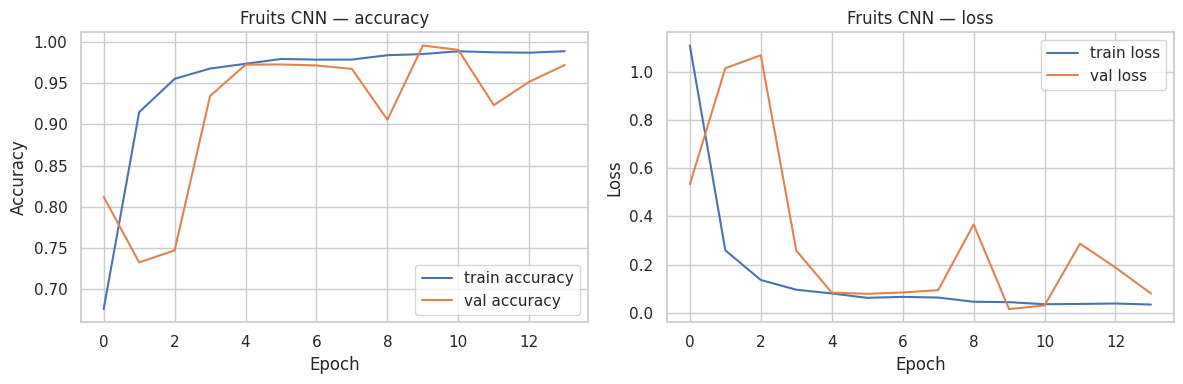

In [11]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist["accuracy"], label="train accuracy")
    axes[0].plot(hist["val_accuracy"], label="val accuracy")
    axes[0].set_title(f"{title} — accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(hist["loss"], label="train loss")
    axes[1].plot(hist["val_loss"], label="val loss")
    axes[1].set_title(f"{title} — loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history, "Fruits CNN")


## 7. Evaluarea modelului

Evaluăm pe setul de **test** (necunoscut modelului): acuratețe, top-3 accuracy, F1-macro/weighted, matricea de confuzie și un grid de predicții.


In [12]:
test_loss, test_acc, test_top3 = model.evaluate(test_ds, verbose=0)
print(f"Test loss:      {test_loss:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Test top-3 acc: {test_top3:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = y_prob.argmax(axis=1)

print(f"Accuracy (sklearn): {accuracy_score(y_true, y_pred):.4f}")
print(f"F1-macro:           {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-weighted:        {f1_score(y_true, y_pred, average='weighted'):.4f}")


Test loss:      0.0944
Test accuracy:  0.9810
Test top-3 acc: 0.9963
Accuracy (sklearn): 0.9810
F1-macro:           0.9786
F1-weighted:        0.9803


In [13]:
report = classification_report(
    y_true, y_pred, target_names=class_names,
    output_dict=True, zero_division=0,
)
report_df = pd.DataFrame(report).T
report_df.loc[["accuracy", "macro avg", "weighted avg"]]


,precision,recall,f1-score,support
accuracy,0.981003,0.981003,0.981003,0.981003
macro avg,0.983404,0.978881,0.978648,22688.000000
weighted avg,0.984148,0.981003,0.980345,22688.000000


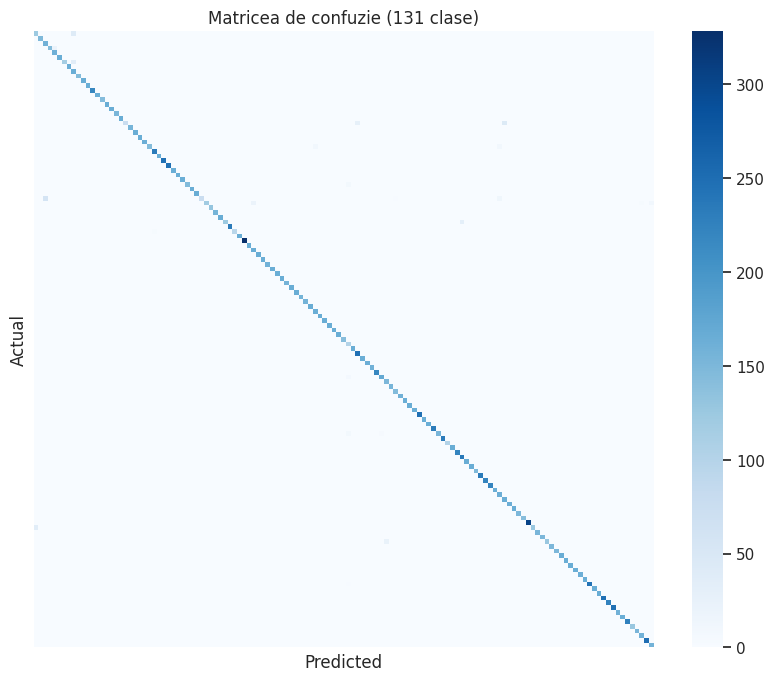

In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", cbar=True, xticklabels=False, yticklabels=False)
plt.title(f"Matricea de confuzie ({num_classes} clase)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


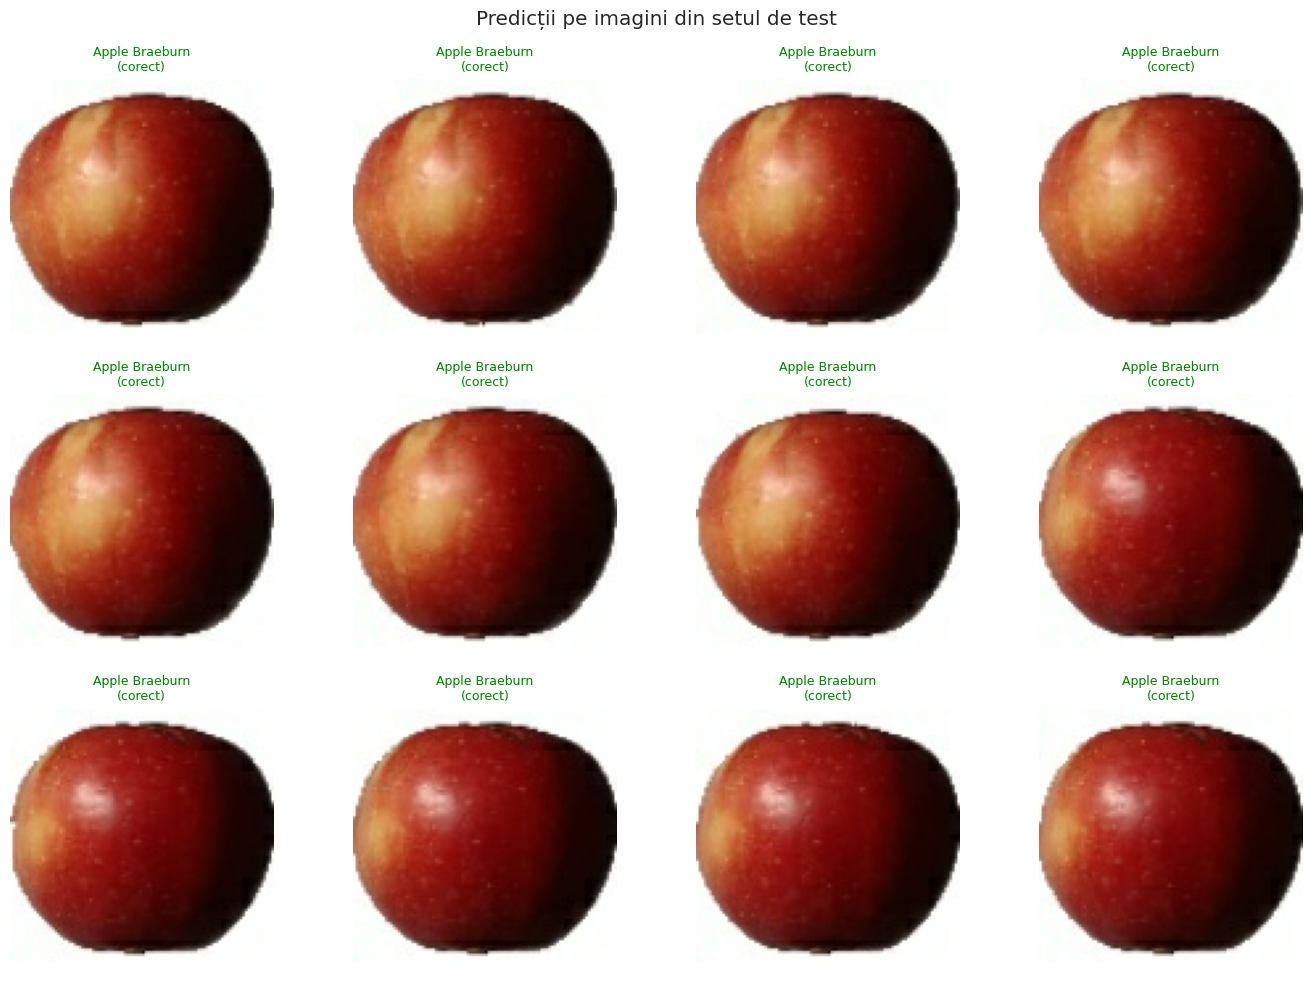

In [15]:
for images, labels in test_ds.take(1):
    probs = model.predict(images, verbose=0)
    preds = probs.argmax(axis=1)
    plt.figure(figsize=(14, 10))
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8).numpy())
        true_n = class_names[labels[i].numpy()]
        pred_n = class_names[preds[i]]
        ok = true_n == pred_n
        ax.set_title(
            f"{pred_n}\n({'corect' if ok else 'real: ' + true_n})",
            color="green" if ok else "red", fontsize=9,
        )
        ax.axis("off")
    plt.suptitle("Predicții pe imagini din setul de test")
    plt.tight_layout()
    plt.show()
    break


## 8. Predicție în timp real

 `predict_image` redimensionează imaginea la `100×100` și întoarce primele 3 sorturi probabile cu încrederea aferentă (modelul are `Rescaling(1/255)` integrat, deci primește pixeli `0–255`).


In [16]:
def predict_image(img_path, topk=3):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    probs = model.predict(tf.expand_dims(arr, 0), verbose=0)[0]
    top = probs.argsort()[-topk:][::-1]
    return img, [(class_names[i], float(probs[i])) for i in top]


Saving VWH-GettyImages-871613240-f0c60fc126404e3abc606d4bfacb7443.jpg to VWH-GettyImages-871613240-f0c60fc126404e3abc606d4bfacb7443.jpg


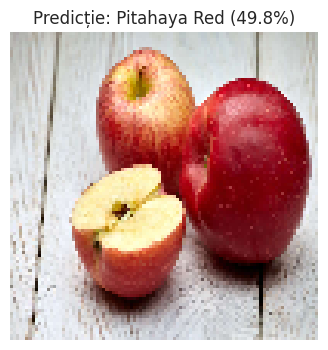

Obiect recunoscut: Pitahaya Red — încredere 49.80%
Top 3 sorturi probabile:
  - Pitahaya Red: 49.80%
  - Lychee: 22.98%
  - Pepper Red: 19.76%


In [17]:
from google.colab import files

uploaded = files.upload()

for fname in uploaded:
    img, top = predict_image(fname)
    best_name, best_conf = top[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicție: {best_name} ({best_conf * 100:.1f}%)")
    plt.show()

    print(f"Obiect recunoscut: {best_name} — încredere {best_conf * 100:.2f}%")
    print("Top 3 sorturi probabile:")
    for name, conf in top:
        print(f"  - {name}: {conf * 100:.2f}%")


## 9. Concluzii

În această lucrare am construit, folosind **TensorFlow / `tf.keras`**, o rețea neuronală convoluțională care **recunoaște sortul de fruct** dintr-o imagine din setul `Fruits-360`. Am parcurs tot fluxul: obținerea datelor prin clonarea repo-ului oficial de pe GitHub, analiza exploratorie (zeci de sorturi, set aproximativ echilibrat), construirea unui pipeline `tf.data` (`image_dataset_from_directory` + `prefetch`), augmentarea datelor, proiectarea unei CNN cu 3 blocuri convoluționale și cap dens cu ieșire `softmax`, antrenarea cu `EarlyStopping` și evaluarea pe un set de test independent.

Sarcina nu se rezumă la separarea unor clase largi, ci la **identificarea fină** a obiectului dintr-o singură categorie (zeci de sorturi de fructe), urmată de **predicție în timp real** pe o imagine încărcată de utilizator. Tehnic, problema rămâne o clasificare multi-clasă, dar cu multe clase și sub-clase vizual asemănătoare — de aceea am urmărit și **top-3 accuracy**.

Datorită imaginilor curate și standardizate din Fruits-360, o CNN proprie, relativ mică, atinge o acuratețe foarte bună. **Batch Normalization** și **Dropout** au stabilizat antrenarea și au limitat supra-antrenarea, iar **augmentarea** ajută generalizarea la fotografii reale. Pentru seturi mai „zgomotoase” (fundal complex, iluminare variabilă), pasul următor firesc ar fi **transfer learning** (ex. MobileNetV2/ResNet pre-antrenate pe ImageNet).

## 10. Întrebări de autoevaluare

#### 1. Care sunt pașii de creare a unui model de recunoaștere a obiectelor sau persoanelor din imagine? Prin ce diferă de CNN pentru clasificare?

Pașii principali sunt:

1. **Definirea problemei** și colectarea unui set cu **o categorie și multe sub-clase fine** (sorturi/identități).
2. **Preprocesare** — citire, redimensionare la rezoluție comună, normalizare, împărțire train/validare/test.
3. **Augmentare** a datelor de antrenare.
4. **Alegerea arhitecturii CNN** (blocuri convoluționale + cap dens).
5. **Funcții de activare** (ReLU în straturile interne, softmax la ieșire).
6. **Loss + optimizator** potrivite problemei.
7. **Antrenare** cu validare și `EarlyStopping`.
8. **Evaluare** (acuratețe, top-k, F1, matrice de confuzie).
9. **Inferență în timp real** pe o imagine încărcată.
10. **Optimizare** (hiperparametri, arhitectură, regularizare).

**Diferența** față de o CNN „de clasificare” obișnuită: tehnic este tot o clasificare, dar aici clasele sunt **fine și numeroase** (ex. sortul mărului: Granny Smith, Golden, Richard), diferențele dintre clase sunt **subtile**, iar scopul este **identificarea** exactă a obiectului dintr-o singură categorie, plus o componentă de **predicție în timp real** pentru o imagine nouă, nu doar separarea câtorva clase largi.

**Diferența** față de o CNN „de clasificare” obișnuită: tehnic este tot o clasificare, dar aici clasele sunt **fine și numeroase** (ex. sortul mărului: Granny Smith, Golden, Richard), diferențele dintre clase sunt **subtile**, iar scopul este **identificarea** exactă a obiectului dintr-o singură categorie, plus o componentă de **predicție în timp real** pentru o imagine nouă, nu doar separarea câtorva clase largi.

#### 2. Ce reprezintă un strat convoluțional? Cum alegem numărul de filtre, mărimea lor? Ce este padding?

Un **strat convoluțional** glisează filtre (nuclee) mici peste imagine și produce **hărți de caracteristici**; fiecare filtru învață un tipar local (margini, texturi, forme). **Numărul de filtre** crește spre adâncime (`32→64→128`) pe măsură ce harta spațială scade și caracteristicile devin mai abstracte. **Mărimea** uzuală este `3×3` (uneori `5×5`/`7×7` la primul strat). **Padding** adaugă un cadru de zerouri: cu `same` ieșirea păstrează dimensiunea spațială, cu `valid` dimensiunea scade după fiecare convoluție.


#### 3. În ce constă preprocesarea setului de date?

**Preprocesarea** transformă imaginile brute într-un format potrivit antrenării unei rețele CNN. Pașii tipici sunt:

1. **Citirea și decodarea** imaginilor (din fișiere sau directoare pe disc).
2. **Redimensionarea** la o rezoluție comună (ex. `100×100`), ca toate intrările să aibă aceeași formă.
3. **Normalizarea** valorilor pixelilor (de ex. scalare în `[0, 1]` prin `Rescaling(1/255)` sau standardizare cu medie și deviație standard), pentru antrenare mai stabilă.
4. **Etichetarea** — asocierea fiecărei imagini cu clasa corectă (de obicei din numele folderului sau dintr-un fișier de metadate).
5. **Împărțirea** setului în **antrenare / validare / test**, eventual cu **amestecare** (shuffle) a exemplelor de antrenare.
6. **Organizarea într-un pipeline de date** (`tf.data`, PyTorch `DataLoader` etc.) cu optimizări precum `prefetch`, pentru a alimenta eficient GPU-ul în loturi.

**Augmentarea datelor** (flip, rotație, zoom etc.) este adesea considerată o extensie a preprocesării, dar se aplică **doar la antrenare**, nu la validare/test, pentru a mări diversitatea fără a altera evaluarea.

#### 4. Cum alegem numărul de straturi convoluționale? Dar numărul de straturi Dense într-o rețea CNN?

Numărul de **straturi convoluționale** depinde de complexitatea imaginilor: 2–4 blocuri pentru imagini simple/standardizate (cazul Fruits-360), mai multe pentru date complexe. Mai multe straturi → caracteristici mai abstracte, dar risc de overfitting și cost mai mare. Pentru **straturile Dense** finale, 1–2 sunt suficiente (unul intern de 128–512 neuroni + stratul de ieșire); puterea unei CNN vine din convoluții, nu din capul dens.

#### 5. Ce funcții de activare folosim în straturile interne? Dar în stratul de ieșire?

În straturile interne: **ReLU** (standard, rapidă, evită saturarea gradientului; variante: Leaky ReLU, ELU). În stratul de ieșire: **softmax** pentru clasificare multi-clasă (aici — sorturi de fructe), sigmoid pentru binar, linear pentru regresie.

#### 6. Ce calculează funcția loss? Care este formula de calcul?

Funcția **loss** măsoară diferența dintre predicția modelului și eticheta reală; antrenarea o minimizează. Pentru clasificare multi-clasă folosim **categorical cross-entropy**:

$$L = -\sum_{c=1}^{C} y_c \,\log(\hat{y}_c)$$

unde $C$ este numărul de clase, $y_c$ eticheta one-hot (1 pentru clasa corectă, 0 în rest) și $\hat{y}_c$ probabilitatea prezisă. În varianta **sparse** (etichete întregi, cum folosim aici) formula se reduce la $L = -\log(\hat{y}_{\text{clasa corectă}})$ — penalizează puternic încrederea mare într-o predicție greșită.

#### 7. Care e scopul normalizării loturilor (Batch Normalization)?

**Batch Normalization** normalizează activările (medie 0, varianță 1) pe fiecare mini-lot, apoi le re-scalează prin doi parametri învățabili. Avantaje: stabilizează gradientul, permite rate de învățare mai mari, accelerează convergența și are un mic efect de regularizare. Se aplică de obicei după stratul convoluțional, în jurul funcției de activare.

#### 8. Cum alegem numărul de epoci pentru antrenare?

Pornim de la o estimare (ex. 15–30) și urmărim curbele de **acuratețe/loss pe validare**: oprim când performanța pe validare **stagnează sau începe să scadă** (semn de overfitting). În practică folosim **`EarlyStopping`** cu `patience` și `restore_best_weights=True` — antrenarea se oprește automat la numărul optim de epoci și se păstrează cele mai bune greutăți.

#### 9. Cum sunt interpretate rezultatele?

Comparăm acuratețea de **train vs validare/test**: apropiate și mari → model bun; train ≫ validare → overfitting; ambele mici → underfitting. **Top-3 accuracy** arată dacă greșelile sunt „aproape corecte” (sorturi similare). **Matricea de confuzie** evidențiază ce clase se confundă între ele, iar **F1-macro** măsoară performanța medie pe clase indiferent de frecvență. Gridul de predicții oferă o verificare vizuală directă.

#### 10. Care sunt pașii de optimizare a unei CNN?

1. **Verifică datele** (echilibru, calitate, augmentare).
2. **Normalizare adecvată** a intrărilor.
3. **Augmentare mai bogată** dacă apare overfitting.
4. **Ajustează arhitectura** (blocuri, filtre, `padding`).
5. **Loss și optimizator potrivite** (Adam `1e-3` ca punct de plecare).
6. **Scade rata de învățare la platou** (`ReduceLROnPlateau`).
7. **Regularizare** (Dropout, BatchNorm, L2).
8. **`EarlyStopping`** pentru a opri antrenarea la momentul optim.
9. **Transfer learning** dacă setul este mic sau zgomotos.
10. **Evaluare finală** pe setul de test independent.
